In [ ]:
#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,LabelEncoder
from sklearn.impute import SimpleImputer

In [ ]:
#load dataset
df=pd.read_csv('/content/Teen_Mental_Health_Dataset.csv')
print('DataSet Loaded Successfully')


DataSet Loaded Successfully


In [ ]:
df.shape

(1200, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1200 non-null   float64
 1   gender                           1200 non-null   int64  
 2   daily_social_media_hours         1200 non-null   float64
 3   platform_usage                   1200 non-null   object 
 4   sleep_hours                      1200 non-null   float64
 5   academic_performance             1200 non-null   float64
 6   anxiety_level                    1200 non-null   int64  
 7   addiction_level                  1200 non-null   int64  
 8   social_interaction_level_high    1200 non-null   bool   
 9   social_interaction_level_low     1200 non-null   bool   
 10  social_interaction_level_medium  1200 non-null   bool   
 11  MentalHealthRisk                 1200 non-null   int64  
 12  PoorSleep           

In [ ]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1191.000000,1200.000000,1200.000000,1198.000000,1200.000000,1197.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.931150,4.536667,6.449417,1.739149,2.990383,1.014536,5.445833,5.636667,5.565000,0.025833
std,2.024712,2.029599,1.442677,0.716434,0.576758,0.582211,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.750000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [ ]:
df.isnull().sum().head()

,0
age,0
gender,0
daily_social_media_hours,0
platform_usage,0
sleep_hours,0


In [ ]:
print("No.of duplicate rows:",df.duplicated().sum())

No.of duplicate rows: 0


In [ ]:
#fill missing values of age by mean
df['age'].fillna(df['age'].mean(),inplace=True)
df['physical_activity'].fillna(df['physical_activity'].mode()[0],inplace=True)

/tmp/ipykernel_776/2481788699.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(),inplace=True)
/tmp/ipykernel_776/2481788699.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [ ]:
df.drop('screen_time_before_sleep',axis=1,inplace=True, errors='ignore')

In [ ]:
df.isnull().sum().head()

,0
age,0
gender,0
daily_social_media_hours,0
platform_usage,0
sleep_hours,0


In [ ]:
#create labelencoder
le=LabelEncoder()
df['gender']=le.fit_transform(df['gender'])
print(df['gender'].head())

0    1
1    0
2    0
3    1
4    0
Name: gender, dtype: int64


In [ ]:
df=pd.get_dummies(df,columns=['social_interaction_level'])

In [ ]:
# The original 'social_interaction_level' column was removed after one-hot encoding.
# To view the newly created dummy variables, you can check the DataFrame's head.
print(df.head())

        age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0  15.93115       1                       7.9      Instagram          7.4   
1  19.00000       0                       1.9         TikTok          8.0   
2  17.00000       0                       1.3      Instagram          7.6   
3  15.00000       1                       7.4         TikTok          6.9   
4  15.00000       0                       4.7           Both          4.9   

   academic_performance  physical_activity  anxiety_level  addiction_level  \
0                  3.01                1.5              2                1   
1                  3.22                0.8              1               10   
2                  3.92                0.0              4                2   
3                  3.48                0.8              7                9   
4                  2.37                1.4              5                2   

   depression_label  social_interaction_level_high  \
0             

In [ ]:
#create MinMaxScaler
scaler=MinMaxScaler()
df[['age','sleep_hours']]=scaler.fit_transform(df[['age','sleep_hours']])
print(df[['age','sleep_hours']].head())

        age  sleep_hours
0  0.488525         0.68
1  1.000000         0.80
2  0.666667         0.72
3  0.333333         0.58
4  0.333333         0.18


In [ ]:
#create a new feature
df['MentalHealthRisk'] = (
    df['anxiety_level'] +
    df['addiction_level']
)

print("MentalHealthRisk feature created without 'stress_level' as it was not found.")

display(df[[
            'anxiety_level',
            'addiction_level',
            'MentalHealthRisk']].head())

MentalHealthRisk feature created without 'stress_level' as it was not found.


,anxiety_level,addiction_level,MentalHealthRisk
0,2,1,3
1,1,10,11
2,4,2,6
3,7,9,16
4,5,2,7


In [ ]:
# Create a new feature 'PoorSleep'
df['PoorSleep'] = df['sleep_hours'].apply(lambda x: 1 if x < 7 else 0)

print("PoorSleep feature created")

display(df[['sleep_hours', 'PoorSleep']].head())

PoorSleep feature created


,sleep_hours,PoorSleep
0,0.68,1
1,0.80,1
2,0.72,1
3,0.58,1
4,0.18,1


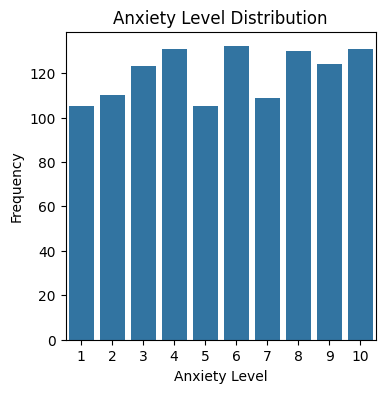

In [ ]:
#(Univariate Visualization)
plt.figure(figsize=(4,4))
sns.countplot(x='anxiety_level',data=df)
plt.title('Anxiety Level Distribution')
plt.xlabel('Anxiety Level')
plt.ylabel('Frequency')
plt.show()

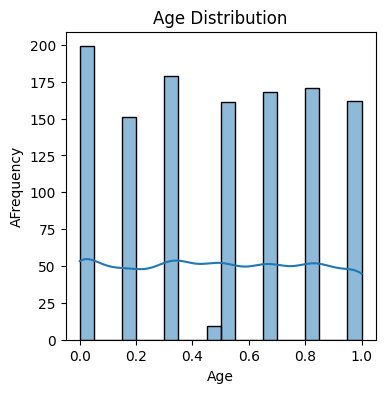

In [ ]:
plt.figure(figsize=(4,4))
sns.histplot(df['age'],bins=20,kde=True)
plt.title('Age Distribution')
plt.xlabel("Age")
plt.ylabel("AFrequency")
plt.show()

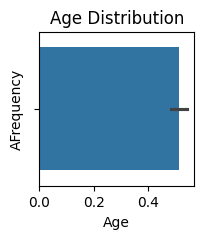

In [ ]:
#bivariate Visualization
plt.figure(figsize=(2,2))
sns.barplot(x='gender',data=df)
plt.title('Age Distribution')
plt.xlabel("Age")
plt.ylabel("AFrequency")
plt.show()

In [ ]:
#outlier detection
Q1=df['age'].quantile(0.25)
Q3=df['age'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=df[(df['age']>=lower_bound) | (df['age']<=upper_bound)]
print("Outliers Removed")

Outliers Removed


In [ ]:
print("After Removing Outliers DataSet Shape:",df.shape)

After Removing Outliers DataSet Shape: (1200, 15)


In [ ]:
#drop columns Name and Ticket
drop_columns = ['physical_activity','depression_label']
df.drop(drop_columns,axis=1,inplace=True)
print("Columns Removed")

Columns Removed


In [ ]:
df.shape

(1200, 13)

In [ ]:
print("After Preprocessing")
display(df.head())

After Preprocessing


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,academic_performance,anxiety_level,addiction_level,social_interaction_level_high,social_interaction_level_low,social_interaction_level_medium,MentalHealthRisk,PoorSleep
0,0.488525,1,7.9,Instagram,0.68,3.01,2,1,False,True,False,3,1
1,1.000000,0,1.9,TikTok,0.80,3.22,1,10,True,False,False,11,1
2,0.666667,0,1.3,Instagram,0.72,3.92,4,2,True,False,False,6,1
3,0.333333,1,7.4,TikTok,0.58,3.48,7,9,False,False,True,16,1
4,0.333333,0,4.7,Both,0.18,2.37,5,2,False,False,True,7,1
